<a href="https://colab.research.google.com/github/irfanalam23/mobile-sales-analytics-report-/blob/main/Copy_of_sales_forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# New Section

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('/content/sample_data/retail_store_inventory-selected-columns.csv')

# Display the first 5 rows of the DataFrame
display(df.head())

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50
1,2022-01-01,S001,P0002,Toys,South,204,150,66,144.04,63.01
2,2022-01-01,S001,P0003,Toys,West,102,65,51,74.02,27.99
3,2022-01-01,S001,P0004,Toys,North,469,61,164,62.18,32.72
4,2022-01-01,S001,P0005,Electronics,East,166,14,135,9.26,73.64


In [ ]:
# Display basic information about the DataFrame (data types, non-null values)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73100 entries, 0 to 73099
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Date             73100 non-null  object 
 1   Store ID         73100 non-null  object 
 2   Product ID       73100 non-null  object 
 3   Category         73100 non-null  object 
 4   Region           73100 non-null  object 
 5   Inventory Level  73100 non-null  int64  
 6   Units Sold       73100 non-null  int64  
 7   Units Ordered    73100 non-null  int64  
 8   Demand Forecast  73100 non-null  float64
 9   Price            73100 non-null  float64
dtypes: float64(2), int64(3), object(5)
memory usage: 5.6+ MB


In [ ]:
# Display descriptive statistics for numerical columns
display(df.describe())

,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price
count,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000
mean,274.469877,136.464870,110.004473,141.494720,55.135108
std,129.949514,108.919406,52.277448,109.254076,26.021945
min,50.000000,0.000000,20.000000,-9.990000,10.000000
25%,162.000000,49.000000,65.000000,53.670000,32.650000
50%,273.000000,107.000000,110.000000,113.015000,55.050000
75%,387.000000,203.000000,155.000000,208.052500,77.860000
max,500.000000,499.000000,200.000000,518.550000,100.000000


In [ ]:
# Convert 'Date' column to datetime objects
df['Date'] = pd.to_datetime(df['Date'])

# Sort the DataFrame by Date to ensure proper time series order
df = df.sort_values(by='Date')

# Display the updated info to confirm the date type conversion
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 73100 entries, 0 to 73099
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Date             73100 non-null  datetime64[ns]
 1   Store ID         73100 non-null  object        
 2   Product ID       73100 non-null  object        
 3   Category         73100 non-null  object        
 4   Region           73100 non-null  object        
 5   Inventory Level  73100 non-null  int64         
 6   Units Sold       73100 non-null  int64         
 7   Units Ordered    73100 non-null  int64         
 8   Demand Forecast  73100 non-null  float64       
 9   Price            73100 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(3), object(4)
memory usage: 6.1+ MB


In [ ]:
# For Prophet, we typically need a single time series. Let's aggregate 'Units Sold' by 'Date'.
# This assumes we want to forecast total units sold across all products/stores.
# If a more granular forecast is needed, the aggregation strategy would change.
daily_sales = df.groupby('Date')['Units Sold'].sum().reset_index()

# Rename columns to 'ds' (datestamp) and 'y' (series to be forecasted) as required by Prophet
daily_sales.rename(columns={'Date': 'ds', 'Units Sold': 'y'}, inplace=True)

# Display the first few rows of the prepared data
display(daily_sales.head())

,ds,y
0,2022-01-01,14484
1,2022-01-02,13415
2,2022-01-03,13681
3,2022-01-04,14084
4,2022-01-05,12572


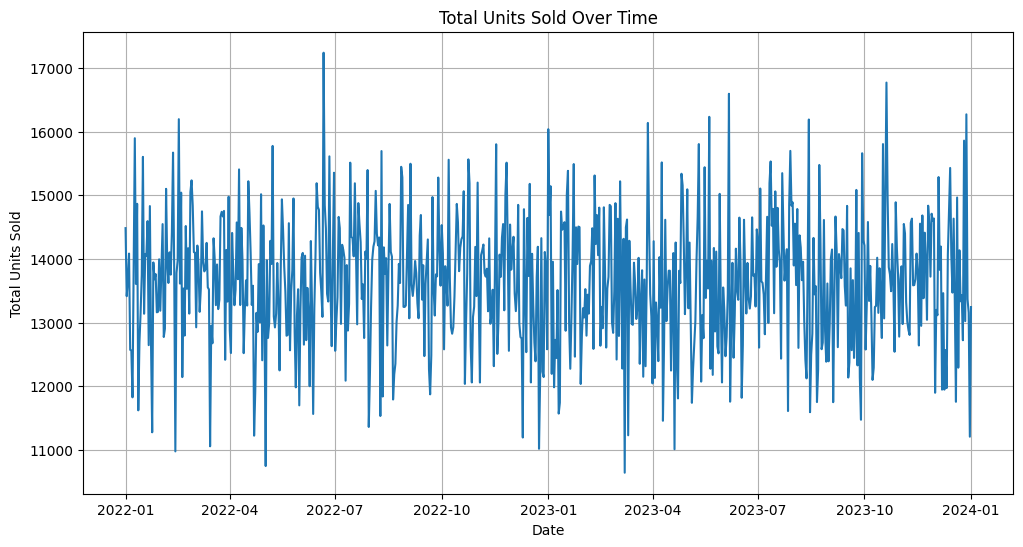

In [ ]:
# Visualize the time series data for 'Units Sold'
plt.figure(figsize=(12, 6))
plt.plot(daily_sales['ds'], daily_sales['y'])
plt.xlabel('Date')
plt.ylabel('Total Units Sold')
plt.title('Total Units Sold Over Time')
plt.grid(True)
plt.show()

In [ ]:
from prophet import Prophet

# Initialize Prophet model. We can add seasonality modes later if needed.
model = Prophet()

# Fit the model on the prepared daily sales data
model.fit(daily_sales)

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [ ]:
# Create a DataFrame with future dates for forecasting
# Let's forecast for the next 30 days (1 month)
future = model.make_future_dataframe(periods=30)

# Display the first few rows of the future DataFrame
display(future.head())

,ds
0,2022-01-01
1,2022-01-02
2,2022-01-03
3,2022-01-04
4,2022-01-05


In [ ]:
# Make predictions
forecast = model.predict(future)

# Display the first few rows of the forecast
display(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].head())

,ds,yhat,yhat_lower,yhat_upper
0,2022-01-01,13445.058917,12156.006761,14728.783557
1,2022-01-02,13607.617155,12204.556908,14821.747491
2,2022-01-03,13448.625177,12084.458969,14762.012124
3,2022-01-04,13679.796097,12455.099161,14944.672543
4,2022-01-05,13621.553401,12251.752094,14872.660722


In [ ]:
from sklearn.metrics import mean_squared_log_error
import numpy as np

# Merge actuals with forecast to calculate metrics on the training period
performance = pd.merge(daily_sales, forecast[['ds', 'yhat']], on='ds', how='inner')

# Ensure no negative values for RMSLE calculation, as log of negative numbers is undefined.
# Replace any negative predictions with a small positive number if they exist.
performance['yhat'] = performance['yhat'].apply(lambda x: max(0, x))

# Calculate RMSLE
# It's important that both actual (y) and predicted (yhat) values are non-negative.
# A small constant (e.g., 1) is often added to avoid log(0) and to handle cases where y or yhat might be 0.
rmsle = np.sqrt(mean_squared_log_error(performance['y'], performance['yhat']))

print(f'Root Mean Squared Logarithmic Error (RMSLE): {rmsle:.4f}')

Root Mean Squared Logarithmic Error (RMSLE): 0.0741


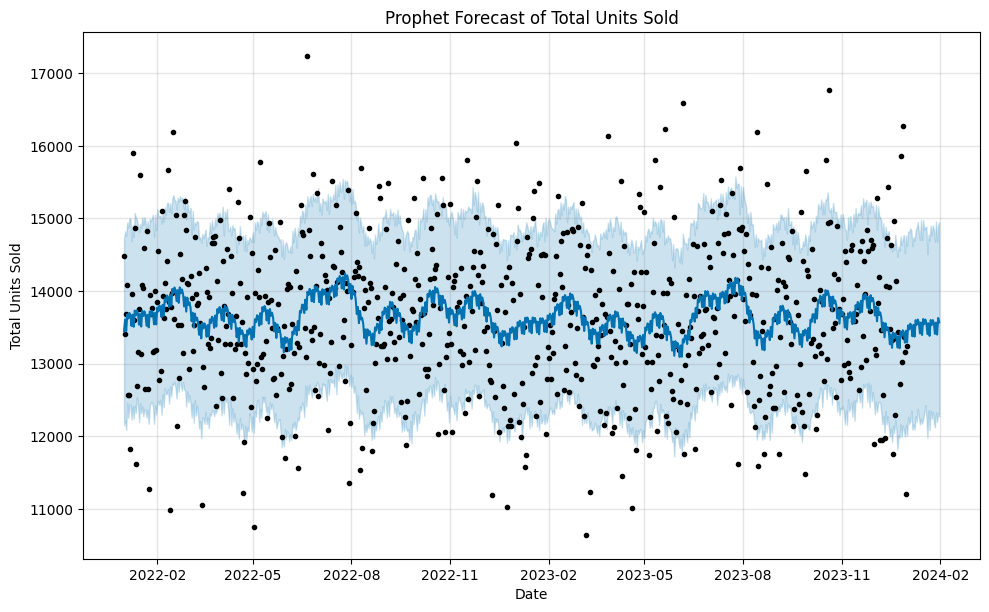

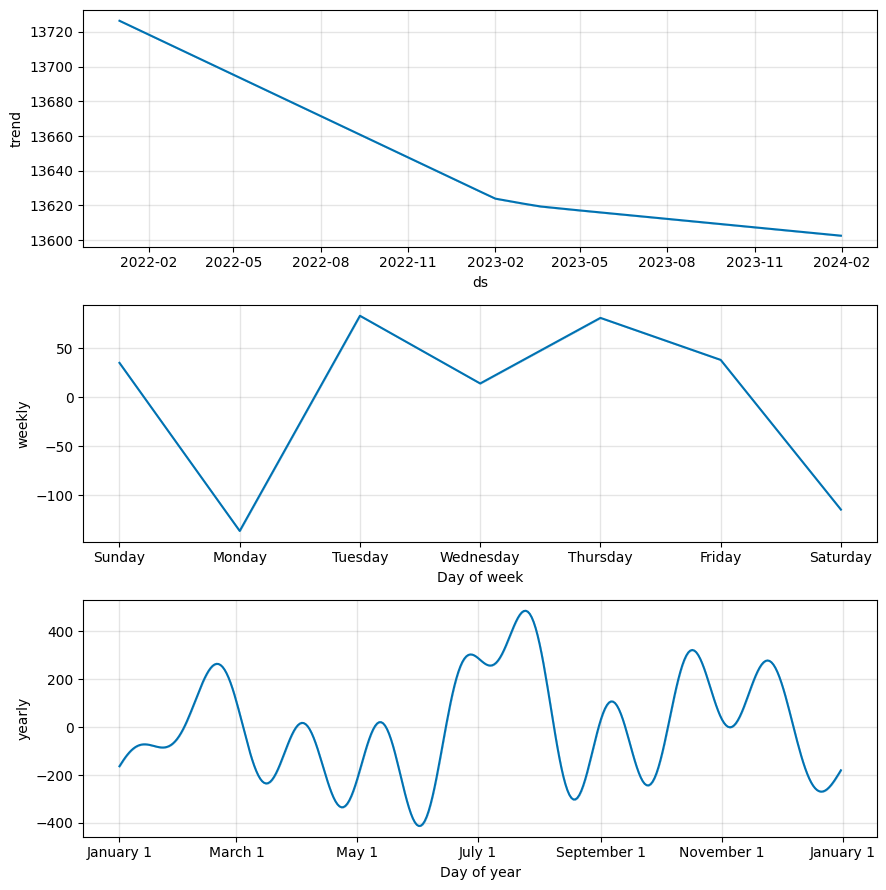

In [ ]:
# Visualize the forecast
fig1 = model.plot(forecast)
plt.title('Prophet Forecast of Total Units Sold')
plt.xlabel('Date')
plt.ylabel('Total Units Sold')
plt.show()

# Visualize the forecast components (trend, weekly, yearly seasonality)
fig2 = model.plot_components(forecast)
plt.show()

In [ ]:
from sklearn.metrics import mean_squared_log_error
import numpy as np

# Merge actuals with forecast to calculate metrics on the training period
performance = pd.merge(daily_sales, forecast[['ds', 'yhat']], on='ds', how='inner')

# Ensure no negative values for RMSLE calculation, as log of negative numbers is undefined.
# Replace any negative predictions with a small positive number if they exist.
performance['yhat'] = performance['yhat'].apply(lambda x: max(0, x))

# Calculate RMSLE
# It's important that both actual (y) and predicted (yhat) values are non-negative.
# A small constant (e.g., 1) is often added to avoid log(0) and to handle cases where y or yhat might be 0.
rmsle = np.sqrt(mean_squared_log_error(performance['y'], performance['yhat']))

print(f'Root Mean Squared Logarithmic Error (RMSLE): {rmsle:.4f}')

Root Mean Squared Logarithmic Error (RMSLE): 0.0741


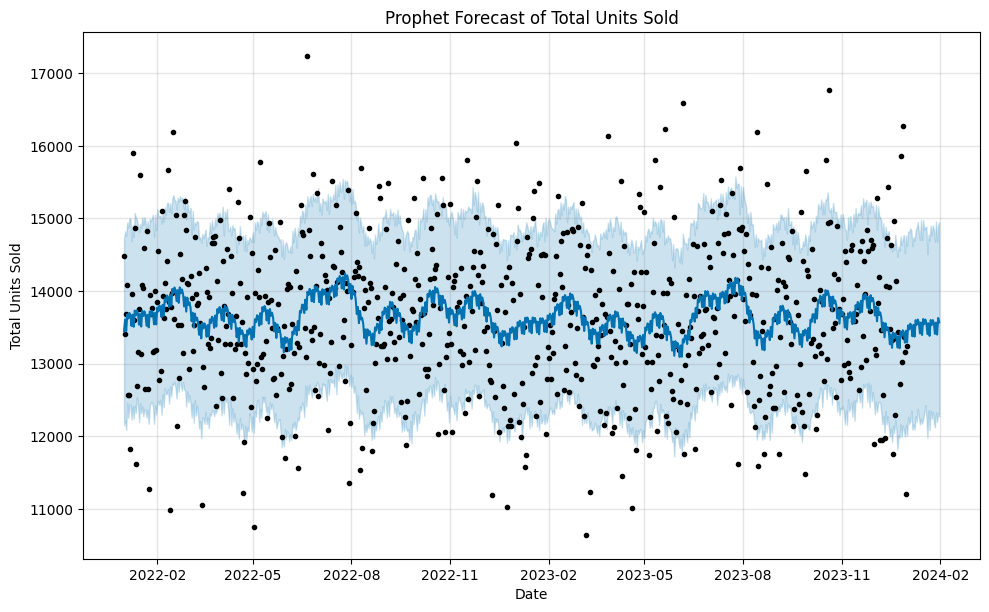

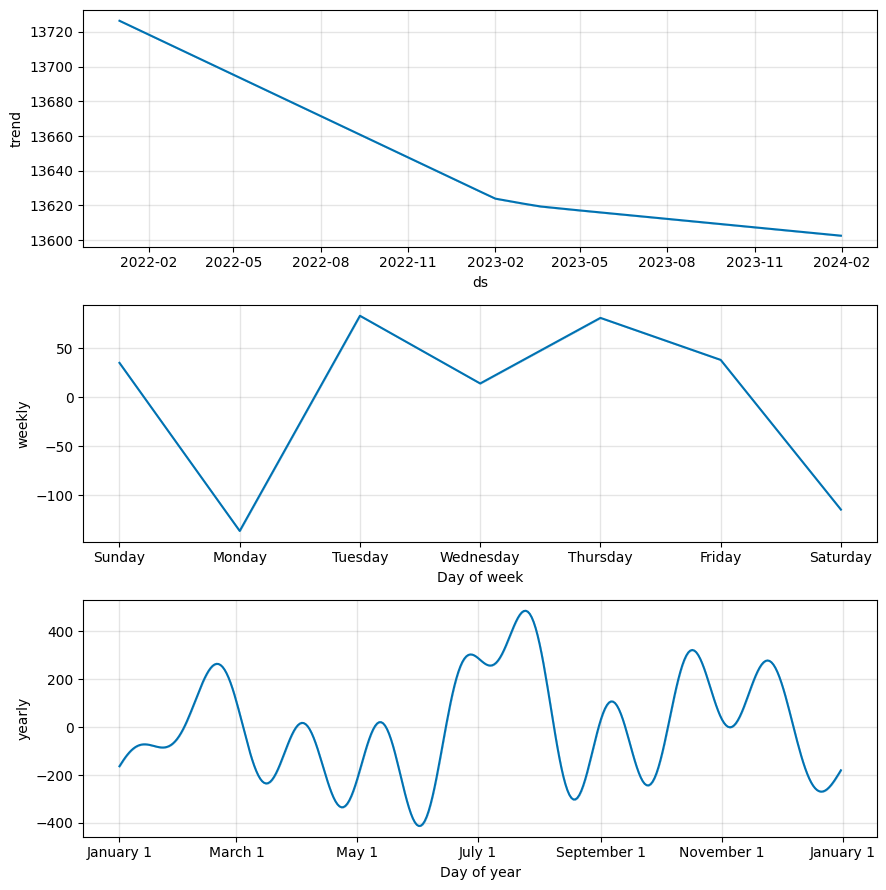

In [ ]:
# Visualize the forecast
fig1 = model.plot(forecast)
plt.title('Prophet Forecast of Total Units Sold')
plt.xlabel('Date')
plt.ylabel('Total Units Sold')
plt.show()

# Visualize the forecast components (trend, weekly, yearly seasonality)
fig2 = model.plot_components(forecast)
plt.show()